<a href="https://colab.research.google.com/github/alitorbzadeh/DeepLearningByPytorch/blob/main/Part1chapter0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [40]:
b_true = 1
w_true = 2
N = 100
np.random.seed(42)
X = np.random.rand(N,1)
epsilon = np.random.randn(N,1)
Y = w_true*X + b_true + epsilon
print(int(0.8*len(Y)))
x_train = X[0:int(0.8*N)]
x_test = X[int(0.8*N):]
y_train = Y[0:int(0.8*N)]
y_test = Y[int(0.8*N):]
# print(f'type(x_train):{len(x_train)}, type(x_test):{len(x_test)}, type(y_train):{len(y_train)}, type(y_test):{len(y_test)}')

80


In [ ]:
data = np.concatenate((x_train,y_train),axis=1)
np.random.shuffle(data)
x_train = data[:,:-1]
y_train = data[:,-1]

In [42]:
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)
print(b,w)

[0.49671415] [-0.1382643]


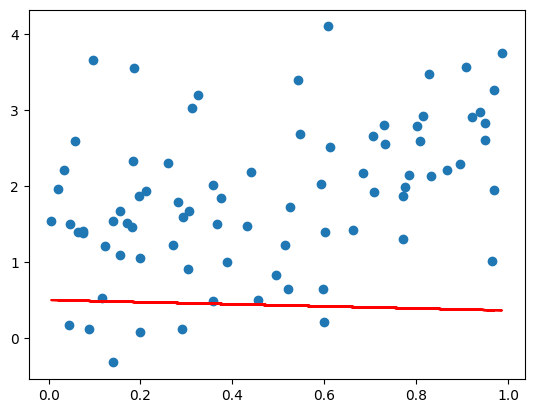

In [43]:
yHat = b + w*x_train
plt.scatter(x_train,y_train)
plt.plot(x_train,yHat,color='red')
plt.show()

<div dir = 'rtl'>

در روش گرادیان کاهشی، اگر تابع هزینه (Loss) را روی تمام N نقطه داده محاسبه کنیم، مسیر به‌روزرسانی پارامترها بسیار پایدار و هموار خواهد بود، اما این کار به دلیل پردازش کل دیتاست در هر مرحله بسیار کند است. برای افزایش سرعت، می‌توان از زیرمجموعه‌ای تصادفی با حجم n از میان N نقطه (بدون جایگزاری) استفاده کرد که منجر به روش سریع‌تر «مینی‌بچ» می‌شود. در این روش اگرچه به دلیل نمونه‌گیری تصادفی، مسیر بهینه‌سازی کمی ناپایدارتر شده و نوسان بیشتری خواهد داشت، اما افزایش چشمگیر سرعت - که می‌تواند ده‌ها برابر باشد - ارزش این قربانی کردن مقدار کمی از پایداری را دارد، و در عمل الگوریتم همچنان به جواب بهینه همگرا می‌شود.

</div>

In [48]:
# Mean Squared Error
error = (yHat-y_train)
loss = (error**2).mean()
print(loss)

3.01818650068689


<div  dir = 'rtl'>

گرادیان به این معنی است که اگر به میزان کوچکی پارامتر یادگیری تغییر کند، MSE به چه میزان تعییر خواهد کرد. ما قراره این را محاسبه کنیم.

</div>

In [49]:
#Calculate Gradiant
b_grad = 2*error.mean()
w_grad = 2*(x_train*error).mean()
print(b_grad,w_grad)

-2.8784218102986863 -1.366546482034717


In [ ]:
#Perform Backpropagation
# we don have more than 1 layer to calculate chain rule gradiant.

<div dir = 'rtl'>

اگر بخواهم خیلی رسمی بگویم:

    پس‌انتشار یعنی گرادیان را از آخرین لایه شروع کن به حساب آوردن: اول ∂Loss/∂ŷ، بعد ∂ŷ/∂a، بعد ∂a/∂w₁. اینطوری هیچ چیز را دوبار محاسبه نمی‌کنی.

</div>